<b><u>PART A: REGRESSION</u></b>


**1. Download & Load the Dataset**

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


In [ ]:
pd.set_option('display.max_rows', None)

In [2]:
pd.reset_option('display.max_rows')

In [43]:
df = pd.read_csv("housing.csv")

In [4]:
df.shape

(20640, 10)

In [5]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


1. Target variable is 'median_house_value'
2. We are predicting the prices of the houses
3. This is supervised learning since we have labeled data
4. This is regression problem as we are trying to predict continuous values

**2. Exploratory Data Analysis (EDA)**

In [7]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [44]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [45]:
imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])

In [46]:
df.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

I use median to fill null values because it avoids skewness in our data

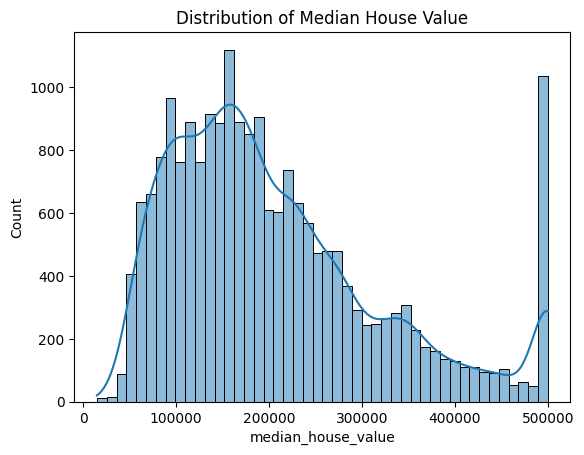

In [41]:
sns.histplot(df['median_house_value'], kde=True)
plt.title('Distribution of Median House Value')
plt.show()

It is skewed

In [47]:
df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

<Axes: >

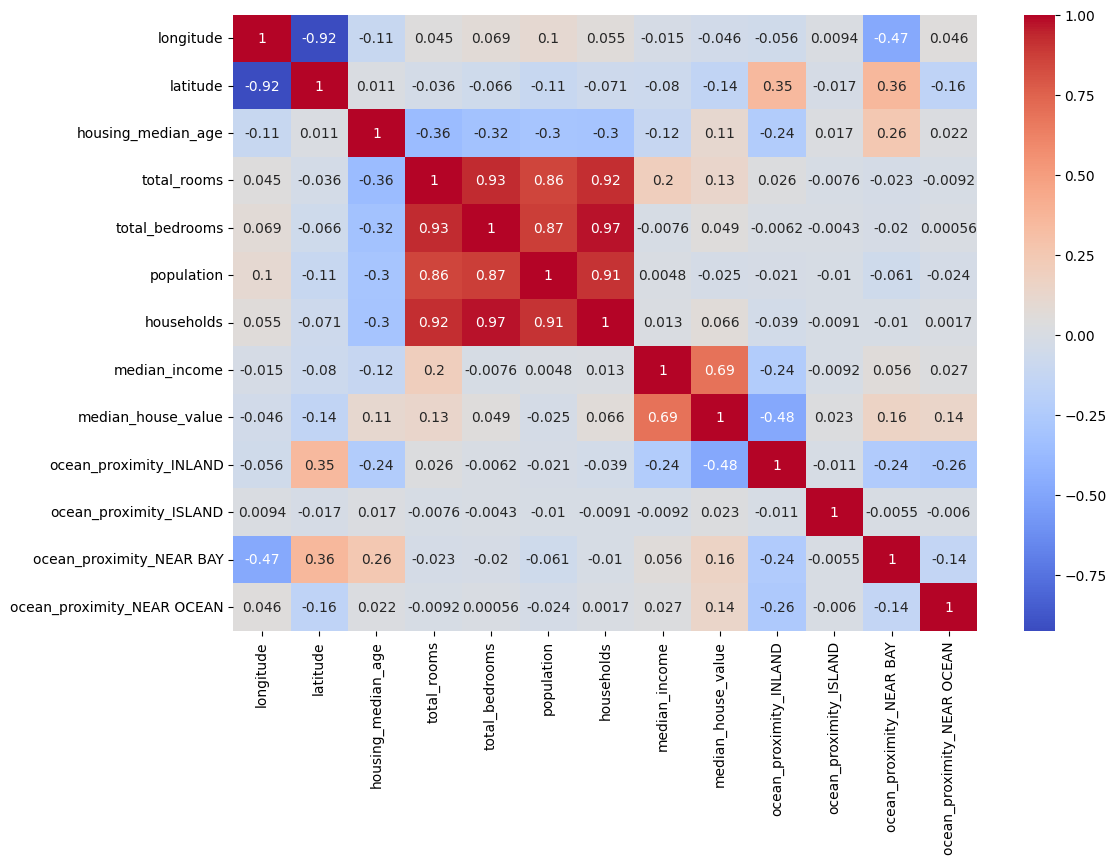

In [48]:
corr_matrix = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot = True, cmap='coolwarm')

<Axes: xlabel='median_income', ylabel='median_house_value'>

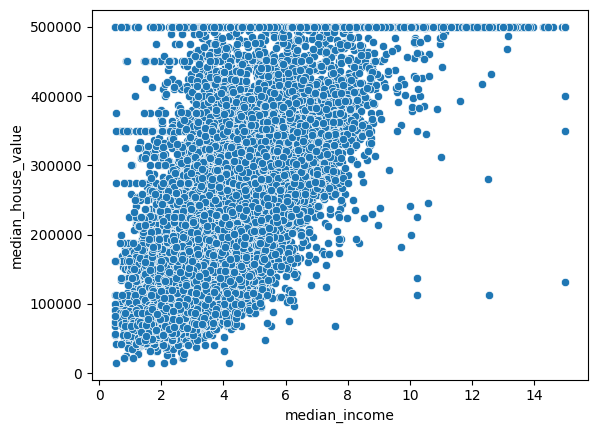

In [49]:
sns.scatterplot(data = df, x = 'median_income', y = 'median_house_value')

<Axes: xlabel='median_house_value', ylabel='median_house_value'>

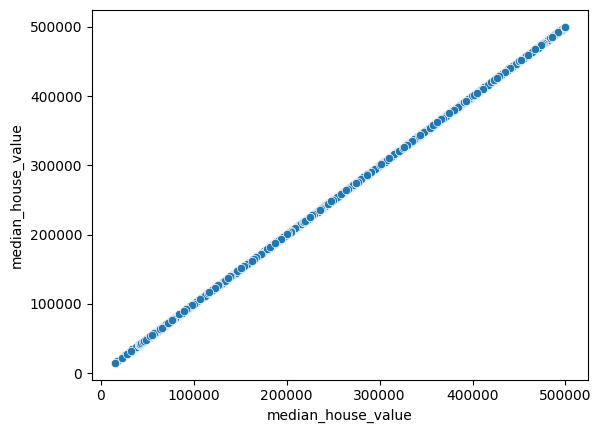

In [50]:
sns.scatterplot(data = df, x = 'median_house_value', y = 'median_house_value')

**3. Data Preparation**

In [28]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [54]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 12)
X_test shape: (4128, 12)
y_train shape: (16512,)
y_test shape: (4128,)


In [57]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

1. We split data to learn patterns from train set and to evaluate model performance on unseen test set
2. If we evaluated model performance on training data only then it will overfit and will perform poorly on new  data
3. We scale features because ridge and lasso are regularized regression models so if one feature has large scale values then it will dominate and become bias. Therefore, scaling ensures that all features contribute equally to the regularization.

**4. Simple Linear Regression**

In [72]:
X_single = df[['median_income']] #I use double [[]] brackets bcz sk learn expect 2D frame for x not 1D series, here frame is (n-samples i.e no of rows, n-features i.e no of columns)
y = df['median_house_value']


In [73]:
X_train_sf, X_test_sf, y_train_sf, y_test_sf = train_test_split(X_single, y, test_size=0.2, random_state=42)

In [74]:
scaler_sf = StandardScaler()
X_train_scaled_sf = scaler_sf.fit_transform(X_train_sf)
X_test_scaled_sf = scaler_sf.transform(X_test_sf)

In [75]:
model_sf = LinearRegression()
model_sf.fit(X_train_scaled_sf, y_train_sf)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [76]:
print("Slope:", model_sf.coef_[0])
print("Intercept:", model_sf.intercept_)

Slope: 79851.95644260356
Intercept: 207194.6937378876


For every one unit increase in median_income, the price increases by 79851 units

In [77]:
y_train_pred = model_sf.predict(X_train_scaled_sf)
y_test_pred = model_sf.predict(X_test_scaled_sf)

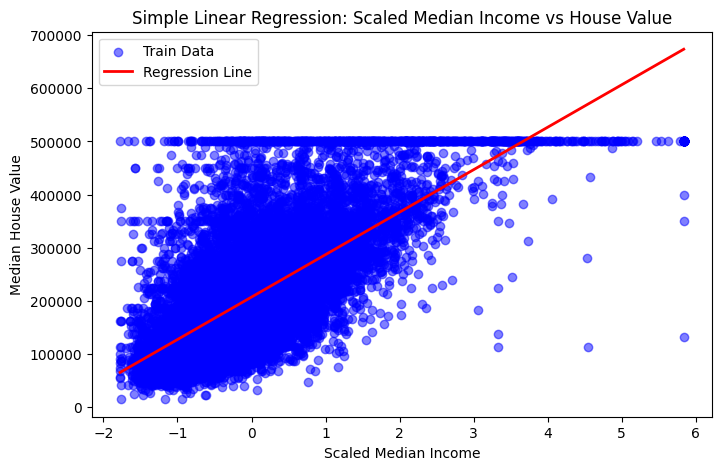

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(X_train_scaled_sf, y_train_sf, alpha=0.5, label='Train Data', color='blue')
x_line = np.linspace(X_train_scaled_sf.min(), X_train_scaled_sf.max(), 100).reshape(-1,1)
y_line = model_sf.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.xlabel('Scaled Median Income')
plt.ylabel('Median House Value')
plt.title('Simple Linear Regression: Scaled Median Income vs House Value')
plt.legend()
plt.show()

In [79]:
r2_train = r2_score(y_train_sf, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train_sf, y_train_pred))
r2_test = r2_score(y_test_sf, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test_sf, y_test_pred))
print(f"Training R²: {r2_train:.3f}, RMSE: {rmse_train:.2f}")
print(f"Test R²: {r2_test:.3f}, RMSE: {rmse_test:.2f}")

Training R²: 0.477, RMSE: 83614.87
Test R²: 0.459, RMSE: 84209.01
